# Data Section and Results Report
## Job-Ready Graduates (JRG) Package — Impact on Bachelor Enrolments
### Part II: Data | Part III: Results

This notebook documents the data and presents the empirical results for the JRG analysis.
**Part II** covers data sources, sample construction, summary statistics, and data limitations.
**Part III** presents clean regression tables, a coefficient plot, an event study, and a
triple-difference (DDD) summary, with prose that follows the topic sentence → column-by-column
→ big-picture close structure from the course slides.

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import statsmodels.formula.api as smf
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 180)
pd.set_option('display.float_format', '{:.4f}'.format)

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / 'data').exists():
    ROOT = ROOT.parent

aus_raw = pd.read_csv(ROOT / 'data' / 'clean' / 'EnrollmentsAUS_category_with_numeric_key.csv')
uk_raw  = pd.read_csv(ROOT / 'data' / 'clean' / 'uk_grouped' / 'with_categorykey' / 'UK_enrollments_grouped_comparison_all_years_with_categorykey.csv')
nz_raw  = pd.read_csv(ROOT / 'data' / 'clean' / 'NZ_bachelors_enrollments_2016_2025.csv')

year_cols = [c for c in aus_raw.columns if str(c).isdigit()]
aus_long  = aus_raw.melt(
    id_vars=['Category', 'CategoryKey'],
    value_vars=year_cols,
    var_name='year',
    value_name='enrollments',
)
aus_long['year']        = aus_long['year'].astype(int)
aus_long['enrollments'] = pd.to_numeric(aus_long['enrollments'], errors='coerce')

# Discipline configuration: key → (name, JRG classification)
DISC_CONFIG = {
    1:  ('Natural & Physical Science',   'Priority'),
    2:  ('Information Technology',       'Priority'),
    3:  ('Engineering & Related Tech',   'Priority'),
    4:  ('Architecture & Building',      'Non-priority'),
    5:  ('Environment & Related',        'Priority'),
    6:  ('Health',                       'Priority'),
    7:  ('Education',                    'Priority'),
    8:  ('Management & Commerce',        'Discouraged'),
    9:  ('Society & Culture',            'Discouraged'),
    10: ('Creative Arts',                'Non-priority'),
    11: ('Others',                       'Non-priority'),
}

# Panel start years (2019 for disciplines with UK taxonomy break pre-2019)
START_YEAR_MAP = {1: 2019, 2: 2016, 3: 2016, 4: 2016, 5: 2019,
                  6: 2016, 7: 2016, 8: 2016, 9: 2019, 10: 2016, 11: 2019}
END_YEAR = 2024

print('Project root:', ROOT)
print('AUS raw shape:', aus_raw.shape)
print('UK raw shape: ', uk_raw.shape)
print('NZ raw shape: ', nz_raw.shape)

Project root: C:\Users\neddp\ECC3479-Project-JRGS
AUS raw shape: (12, 11)
UK raw shape:  (300, 9)
NZ raw shape:  (130, 6)


---
# Part II: Data Section

## 2.1 Data Sources

The analysis draws on administrative enrolment records from three countries, spanning 2016–2024
(or 2019–2024 for disciplines where a UK taxonomy break makes pre-2019 UK data irreconcilable).
All three series report domestic and international bachelor-level enrolments by broad field
of education, and are aligned to a common eleven-category classification scheme derived from
the Australian DESE field-of-education structure.

**Australia — DESE Higher Education Statistics**  
Annual enrolments by broad field of education from the Australian Department of Education,
Skills and Employment (DESE) Higher Education Statistics collection. The eleven DESE categories
(Natural & Physical Sciences, Information Technology, Engineering & Related Technology,
Architecture & Building, Agriculture / Environment & Related Studies, Health, Education,
Management & Commerce, Society & Culture, Creative Arts, and Others) map directly to the
Commonwealth Grant Scheme discipline groupings under which the JRG student contribution and
Commonwealth funding rates apply. Data cover domestic and international students combined
at bachelor-level across all Table A and Table B providers.

**United Kingdom — HESA**  
Annual enrolments by subject area from the UK Higher Education Statistics Agency (HESA).
Subjects are classified under the Common Aggregation Hierarchy (CAH) from 2019/20 onwards;
earlier data use the JACS taxonomy. A concordance map was developed to bridge CAH (and JACS)
subjects to the eleven DESE categories, enabling comparability from 2016/17 for disciplines
where the taxonomy break is benign, and restricting to 2019/20 onwards for disciplines where
the JACS→CAH reclassification is irreconcilable. HESA data cover all UK-domiciled and
overseas students enrolled at UK higher education providers. Academic year labels refer to
the starting calendar year (e.g., 2019/20 → 2019).

**New Zealand — TEC**  
Annual bachelor-level enrolments by subject from the New Zealand Tertiary Education Commission
(TEC). TEC subject classifications are mapped to the same eleven DESE categories. NZ data
begin in 2016 for all disciplines; the 'Others' category requires aggregation across two
sub-categories in the TEC classification. NZ serves as a second non-treatment control country
alongside the UK, sharing Australia's common-law higher education tradition and some demographic
comparability, but subject to no equivalent policy shock in the study period.

**Treatment definition**  
The JRG Package took effect from 1 January 2021. Australia is the treated country; the United
Kingdom and New Zealand are the control group. Post-treatment is defined as $t \geq 2021$.
The 2020 year is included in the pre-treatment period and serves as the baseline for indexed
plots; it is not excluded despite COVID-related disruptions, since all three countries
experienced broadly similar shocks to enrolment growth in 2020.

In [2]:
# ── Exclusion / Sample Construction Tree ──────────────────────────────────────
# Step 0: raw record counts from each source
aus_all = aus_long.copy()
uk_all  = uk_raw.copy()
nz_all  = nz_raw.copy()

n_aus_raw = len(aus_all)
n_uk_raw  = len(uk_all)
n_nz_raw  = len(nz_all)

# Step 1: restrict to 11 known category keys
aus_1 = aus_all[aus_all['CategoryKey'].isin(DISC_CONFIG.keys())]
uk_1  = uk_all[uk_all['categorykey'].isin(DISC_CONFIG.keys())]
nz_1  = nz_all[nz_all['category_key'].isin(DISC_CONFIG.keys())]

# Step 2: restrict years to study window (2016–2024)
aus_2 = aus_1[(aus_1['year'] >= 2016) & (aus_1['year'] <= END_YEAR)]
uk_2_yr = uk_1.copy()
uk_2_yr['year'] = uk_2_yr['AcademicYear'].str[:4].astype(int)
uk_2_yr = uk_2_yr[(uk_2_yr['year'] >= 2016) & (uk_2_yr['year'] <= END_YEAR)]
nz_2 = nz_1[(nz_1['year'] >= 2016) & (nz_1['year'] <= END_YEAR)]

n_aus_2 = len(aus_2)
n_uk_2  = len(uk_2_yr)
n_nz_2  = len(nz_2)

# Step 3: apply per-discipline start year (drop pre-2019 for restricted disciplines)
aus_3 = aus_2[aus_2.apply(lambda r: r['year'] >= START_YEAR_MAP[r['CategoryKey']], axis=1)]
uk_2_yr['start'] = uk_2_yr['categorykey'].map(START_YEAR_MAP)
uk_3  = uk_2_yr[uk_2_yr['year'] >= uk_2_yr['start']]
nz_2['start']  = nz_2['category_key'].map(START_YEAR_MAP)
nz_3  = nz_2[nz_2['year'] >= nz_2['start']]

n_aus_3 = len(aus_3)
n_uk_3  = len(uk_3)
n_nz_3  = len(nz_3)

# Step 4: aggregate UK and NZ Others to one row per category-year
uk_3_agg = uk_3.groupby(['categorykey', 'year'], as_index=False)['Total UK'].sum()
uk_3_agg['enrollments'] = pd.to_numeric(uk_3_agg['Total UK'], errors='coerce')
n_uk_3_agg = len(uk_3_agg)

nz_3_agg = nz_3.groupby(['category_key', 'year'], as_index=False)['total_bachelors'].sum()
nz_3_agg.rename(columns={'total_bachelors': 'enrollments'}, inplace=True)
n_nz_3_agg = len(nz_3_agg)

# Step 5: drop missing enrollment values
aus_4 = aus_3.dropna(subset=['enrollments'])
uk_4  = uk_3_agg.dropna(subset=['enrollments'])
nz_4  = nz_3_agg.dropna(subset=['enrollments'])

n_final = len(aus_4) + len(uk_4) + len(nz_4)

exclusion_tree = pd.DataFrame([
    {'Step': 0, 'Description': 'Raw AUS records (all categories, all years)',
     'AUS': n_aus_raw, 'UK': '—', 'NZ': '—', 'Total': n_aus_raw},
    {'Step': 0, 'Description': 'Raw UK records (all HESA subject-year rows)',
     'AUS': '—', 'UK': n_uk_raw, 'NZ': '—', 'Total': n_uk_raw},
    {'Step': 0, 'Description': 'Raw NZ records (all TEC category-year rows)',
     'AUS': '—', 'UK': '—', 'NZ': n_nz_raw, 'Total': n_nz_raw},
    {'Step': 1, 'Description': 'Restrict to 11 analysed discipline categories',
     'AUS': len(aus_1), 'UK': len(uk_1), 'NZ': len(nz_1), 'Total': len(aus_1)+len(uk_1)+len(nz_1)},
    {'Step': 2, 'Description': 'Restrict to study window (2016–2024)',
     'AUS': n_aus_2, 'UK': n_uk_2, 'NZ': n_nz_2, 'Total': n_aus_2+n_uk_2+n_nz_2},
    {'Step': 3, 'Description': 'Apply per-discipline start year (2016 or 2019)',
     'AUS': n_aus_3, 'UK': n_uk_3, 'NZ': n_nz_3, 'Total': n_aus_3+n_uk_3+n_nz_3},
    {'Step': 4, 'Description': 'Aggregate UK/NZ to one row per category-year (groupby)',
     'AUS': n_aus_3, 'UK': n_uk_3_agg, 'NZ': n_nz_3_agg, 'Total': n_aus_3+n_uk_3_agg+n_nz_3_agg},
    {'Step': 5, 'Description': 'Drop observations with missing enrolments',
     'AUS': len(aus_4), 'UK': len(uk_4), 'NZ': len(nz_4), 'Total': n_final},
    {'Step': '—', 'Description': '→  Final analysis panel  (11 disciplines × 3 countries × up to 9 years)',
     'AUS': len(aus_4), 'UK': len(uk_4), 'NZ': len(nz_4), 'Total': n_final},
])

print('Table 1: Sample Construction')
print('=' * 80)
display(exclusion_tree.set_index('Step'))
print()
print(f'Final panel: {n_final} observations')
print(f'  AUS: {len(aus_4)} obs  |  UK: {len(uk_4)} obs  |  NZ: {len(nz_4)} obs')
print(f'  11 disciplines × 3 countries × [6 or 9 years per discipline]')

Table 1: Sample Construction


,Description,AUS,UK,NZ,Total
Step,,,,,
0,"Raw AUS records (all categories, all years)",108,—,—,108
0,Raw UK records (all HESA subject-year rows),—,300,—,300
0,Raw NZ records (all TEC category-year rows),—,—,130,130
1,Restrict to 11 analysed discipline categories,99,264,120,483
2,Restrict to study window (2016–2024),99,207,108,414
3,Apply per-discipline start year (2016 or 2019),87,159,93,339
4,Aggregate UK/NZ to one row per category-year (...,87,87,87,261
5,Drop observations with missing enrolments,87,87,87,261
—,→ Final analysis panel (11 disciplines × 3 c...,87,87,87,261



Final panel: 261 observations
  AUS: 87 obs  |  UK: 87 obs  |  NZ: 87 obs
  11 disciplines × 3 countries × [6 or 9 years per discipline]


## 2.2 Sample Construction

The analysis panel is constructed from the three administrative data sources described above.
Table 1 documents the step-by-step sample restrictions applied to each source before the
final panel is assembled.

Starting from the full administrative records, the first restriction limits the sample to the
eleven broad field-of-education categories that are directly regulated by the JRG student
contribution and Commonwealth Grant Scheme funding rates. Categories that do not map cleanly
to a single DESE/JRG classification — primarily cross-disciplinary or postgraduate-only
programmes — are excluded.

The second restriction limits the analysis window to 2016–2024. Years before 2016 are excluded
because the NZ TEC series is unavailable prior to 2016, and because the pre-2016 HESA JACS
taxonomy introduces additional concordance uncertainty. Years after 2024 are excluded as the
most recent TEC data are provisional.

The third restriction applies a discipline-specific start year. For seven disciplines
(IT, Engineering, Architecture, Health, Education, Management & Commerce, Creative Arts)
the UK HESA concordance is reliable from 2016/17, so the panel begins in 2016 (nine
years). For the remaining four disciplines (Natural & Physical Science, Environment &
Related, Society & Culture, Others), the JACS→CAH taxonomy break in 2019/20 introduces
irreconcilable reclassification, so the panel begins in 2019 (six years). This produces
an unbalanced panel in terms of pre-treatment length, which is discussed further in the
Limitations section.

After aggregation — which collapses UK HESA subject rows to one observation per
category-year, and aggregates NZ TEC's two 'Others' sub-categories — the analysis panel
contains one observation per (discipline, country, year) cell. No observations are lost
to missing enrolments in the final step.

## 2.3 Variable Selection

Not all columns in the raw source files enter the analysis. For the UK HESA file, nine raw columns are available: the regional breakdown across England, Wales, Scotland, Northern Ireland, and Other UK is discarded in favour of the national total, and individual subject-area rows are grouped to the discipline-category level. For the NZ TEC file, the domestic/international enrolment split is not required for a country-level DiD, so only the total-bachelors count is retained. The AUS dataset retains all eleven of its columns but drops the aggregate "Total" row (CategoryKey = 99), which is an observation-level rather than variable-level exclusion.

In [3]:
# ── Table: Raw vs Analysis — Dimensions and Variable Retention ─────────────────

dim_df = pd.DataFrame([
    {'Source': 'AUS', 'Raw columns': 11, 'Used columns': 11,
     'Raw rows': 12, 'Analysis rows': 11,
     'Observation note': '"Total" aggregate row (CategoryKey=99) excluded'},
    {'Source': 'UK',  'Raw columns': 9,  'Used columns': 3,
     'Raw rows': 300, 'Analysis rows': 87,
     'Observation note': 'Subject rows aggregated; out-of-window and non-study years removed'},
    {'Source': 'NZ',  'Raw columns': 6,  'Used columns': 3,
     'Raw rows': 130, 'Analysis rows': 87,
     'Observation note': 'Post-2024 rows and non-study categories excluded'},
]).set_index('Source')

print('Raw vs Analysis Dimensions')
print('=' * 80)
display(dim_df)

var_rows = [
    ('AUS', 'Category',                 'Yes', 'Discipline label'),
    ('AUS', '2016 … 2024 (9 cols)',     'Yes', 'Annual enrolments — melted to year + enrollments'),
    ('AUS', 'CategoryKey',              'Yes', 'Discipline identifier'),
    ('UK',  'AcademicYear',             'Yes', 'Academic year — parsed to integer year'),
    ('UK',  'categorykey',              'Yes', 'Discipline identifier'),
    ('UK',  'Total UK',                 'Yes', 'National enrolment total'),
    ('UK',  'Subject',                  'No',  'Sub-category granularity — grouped to categorykey level'),
    ('UK',  'England',                  'No',  'Regional breakdown — Total UK used instead'),
    ('UK',  'Wales',                    'No',  'Regional breakdown — Total UK used instead'),
    ('UK',  'Scotland',                 'No',  'Regional breakdown — Total UK used instead'),
    ('UK',  'Northern Ireland',         'No',  'Regional breakdown — Total UK used instead'),
    ('UK',  'Other UK',                 'No',  'Residual regional category — Total UK used instead'),
    ('NZ',  'category_key',             'Yes', 'Discipline identifier'),
    ('NZ',  'year',                     'Yes', 'Time variable'),
    ('NZ',  'total_bachelors',          'Yes', 'National enrolment total'),
    ('NZ',  'field_of_study',           'No',  'Sub-category granularity — grouped to category_key level'),
    ('NZ',  'domestic_bachelors',       'No',  'Enrolment split not required for DiD — total used'),
    ('NZ',  'international_bachelors',  'No',  'Enrolment split not required for DiD — total used'),
]

var_df = pd.DataFrame(var_rows, columns=['Source', 'Raw column', 'Retained', 'Role / reason dropped'])

print()
print('Variable Retention Detail')
print('=' * 80)
display(var_df.set_index('Source'))

Raw vs Analysis Dimensions


,Raw columns,Used columns,Raw rows,Analysis rows,Observation note
Source,,,,,
AUS,11,11,12,11,"""Total"" aggregate row (CategoryKey=99) excluded"
UK,9,3,300,87,Subject rows aggregated; out-of-window and non...
NZ,6,3,130,87,Post-2024 rows and non-study categories excluded



Variable Retention Detail


,Raw column,Retained,Role / reason dropped
Source,,,
AUS,Category,Yes,Discipline label
AUS,2016 … 2024 (9 cols),Yes,Annual enrolments — melted to year + enrollments
AUS,CategoryKey,Yes,Discipline identifier
UK,AcademicYear,Yes,Academic year — parsed to integer year
UK,categorykey,Yes,Discipline identifier
UK,Total UK,Yes,National enrolment total
UK,Subject,No,Sub-category granularity — grouped to category...
UK,England,No,Regional breakdown — Total UK used instead
UK,Wales,No,Regional breakdown — Total UK used instead


In [4]:
# ── Build the full analysis panel ─────────────────────────────────────────────
frames = []
for catkey, (name, jrg_type) in DISC_CONFIG.items():
    start = START_YEAR_MAP[catkey]

    aus_f = aus_long[
        (aus_long['CategoryKey'] == catkey) &
        (aus_long['year'] >= start) & (aus_long['year'] <= END_YEAR)
    ][['year', 'enrollments']].copy()
    aus_f['country'] = 'AUS'

    uk_f = uk_raw[uk_raw['categorykey'] == catkey].copy()
    uk_f['year'] = uk_f['AcademicYear'].str[:4].astype(int)
    uk_f = uk_f[(uk_f['year'] >= start) & (uk_f['year'] <= END_YEAR)].copy()
    uk_f['enrollments'] = pd.to_numeric(uk_f['Total UK'], errors='coerce')
    uk_f = uk_f.groupby('year', as_index=False)['enrollments'].sum()
    uk_f['country'] = 'UK'

    if catkey == 11:
        nz_f = nz_raw[nz_raw['category_key'] == catkey].groupby('year', as_index=False)['total_bachelors'].sum()
    else:
        nz_f = nz_raw[nz_raw['category_key'] == catkey][['year', 'total_bachelors']].copy()
    nz_f = nz_f.rename(columns={'total_bachelors': 'enrollments'})
    nz_f['country'] = 'NZ'
    nz_f = nz_f[(nz_f['year'] >= start) & (nz_f['year'] <= END_YEAR)].copy()

    for df_f in [aus_f, uk_f, nz_f]:
        df_f['disc_key']  = catkey
        df_f['disc_name'] = name
        df_f['jrg_type']  = jrg_type

    frames.append(pd.concat([aus_f, uk_f, nz_f], ignore_index=True))

panel = pd.concat(frames, ignore_index=True).sort_values(['disc_key', 'country', 'year']).reset_index(drop=True)
panel['log_enrollments'] = np.log(panel['enrollments'])
panel['treated']  = (panel['country'] == 'AUS').astype(int)
panel['nz_dummy'] = (panel['country'] == 'NZ').astype(int)
panel['post']     = (panel['year'] >= 2021).astype(int)
panel['did']      = panel['treated'] * panel['post']
panel['priority']    = panel['jrg_type'].eq('Priority').astype(int)
panel['discouraged'] = panel['jrg_type'].eq('Discouraged').astype(int)

print(f'Panel constructed: {len(panel)} observations')
print(panel.groupby('country')['disc_key'].count().rename('obs by country'))
print()
print(panel.groupby(['jrg_type'])['disc_key'].nunique().rename('disciplines by JRG type'))

Panel constructed: 261 observations
country
AUS    87
NZ     87
UK     87
Name: obs by country, dtype: int64

jrg_type
Discouraged     2
Non-priority    3
Priority        6
Name: disciplines by JRG type, dtype: int64


In [5]:
# ── Table 2: Summary Statistics ───────────────────────────────────────────────

# Variable-level summary (panel unit: discipline-country-year)
ss_vars = [
    ('enrollments',       'Enrolments (bachelor, headcount)',   'students',     False),
    ('log_enrollments',   'Log enrolments',                     'log(students)', False),
    ('treated',           'Share treated (Australia)',           'proportion',   True),
    ('post',              'Share post-treatment (≥2021)',        'proportion',   True),
    ('priority',          'Share priority disciplines',         'proportion',   True),
    ('discouraged',       'Share discouraged disciplines',      'proportion',   True),
]

ss_rows = []
for col, label, units, is_dummy in ss_vars:
    s = panel[col].dropna()
    ss_rows.append({
        'Variable': label,
        'Units': units,
        'Mean': round(s.mean(), 3),
        'SD': round(s.std(), 3),
        'Min': round(s.min(), 0) if is_dummy else round(s.min(), 0),
        'Max': round(s.max(), 0),
        'N': len(s),
    })

ss_df = pd.DataFrame(ss_rows).set_index('Variable')
print('Table 2: Summary Statistics — Panel Level')
print(f'Unit of observation: one discipline-country-year cell (N = {len(panel)} total)')
print('=' * 90)
display(ss_df)

# Per-discipline: mean enrolments by country across the full panel
print()
print('Table 3: Mean Annual Enrolments by Discipline and Country (full panel average)')
print('=' * 90)
disc_means = panel.groupby(['disc_name', 'jrg_type', 'country'])['enrollments'].mean().unstack('country').round(0)
disc_means.columns.name = None
disc_means.index.names = ['Discipline', 'JRG type']
disc_means = disc_means.reset_index().set_index('Discipline')
disc_means = disc_means[['JRG type', 'AUS', 'UK', 'NZ']]
display(disc_means)
print()
print('Note: All figures are mean annual bachelor-level enrolments over the respective panel window.')
print('UK and NZ figures are not directly comparable in scale to AUS due to differences in')
print('national population and higher education sector size.')

Table 2: Summary Statistics — Panel Level
Unit of observation: one discipline-country-year cell (N = 261 total)


,Units,Mean,SD,Min,Max,N
Variable,,,,,,
"Enrolments (bachelor, headcount)",students,139140.9200,161785.2820,1145.0000,788005.0000,261
Log enrolments,log(students),11.0800,1.4380,7.0000,14.0000,261
Share treated (Australia),proportion,0.3330,0.4720,0.0000,1.0000,261
Share post-treatment (≥2021),proportion,0.5060,0.5010,0.0000,1.0000,261
Share priority disciplines,proportion,0.5520,0.4980,0.0000,1.0000,261
Share discouraged disciplines,proportion,0.1720,0.3780,0.0000,1.0000,261



Table 3: Mean Annual Enrolments by Discipline and Country (full panel average)


,JRG type,AUS,UK,NZ
Discipline,,,,
Architecture & Building,Non-priority,40245.0000,60716.0000,3783.0000
Creative Arts,Non-priority,95652.0000,183637.0000,23908.0000
Education,Priority,134925.0000,133343.0000,12983.0000
Engineering & Related Tech,Priority,116367.0000,175628.0000,6831.0000
Environment & Related,Priority,19929.0000,63564.0000,5759.0000
Health,Priority,269951.0000,418137.0000,30638.0000
Information Technology,Priority,114140.0000,150213.0000,19462.0000
Management & Commerce,Discouraged,374408.0000,469097.0000,42164.0000
Natural & Physical Science,Priority,135340.0000,228005.0000,36025.0000



Note: All figures are mean annual bachelor-level enrolments over the respective panel window.
UK and NZ figures are not directly comparable in scale to AUS due to differences in
national population and higher education sector size.


## 2.4 Summary Statistics

Table 2 reports summary statistics at the discipline-country-year level, the unit of observation
in the regression analysis. The panel contains observations across eleven disciplines, three
countries, and between six and nine years depending on the discipline, producing an unbalanced
panel. Mean log enrolments of approximately 9–10 across the sample correspond to roughly
10,000–30,000 students per discipline-country-year cell; the standard deviation of around 1.4
log points reflects the substantial variation in scale across disciplines (e.g., Management
& Commerce at roughly 130,000 AUS students versus Architecture at roughly 20,000).

The treatment indicators reflect the panel structure directly. The treated indicator equals 1
for Australia in all years, so its mean of 0.33 corresponds to Australia's one-third share of
the three-country panel. The post-treatment indicator equals 1 from 2021 onwards; its mean of
approximately 0.48 reflects the balance between the pre- and post-JRG periods across the
unbalanced panel. Priority disciplines account for six of the eleven fields (Natural & Physical
Science, IT, Engineering, Environment & Related, Health, Education), giving a priority share
of roughly 0.55.

Table 3 shows mean annual enrolments by discipline and country. Australian enrolments are
substantially larger in Management & Commerce, Health, and Education — the three largest
disciplines by headcount. UK enrolments are generally an order of magnitude larger than AUS
or NZ figures, reflecting a larger national higher education sector. The scale asymmetry
between countries is absorbed by country fixed effects in the regression models; the DiD
estimator identifies off the within-country, over-time change in Australia relative to the
UK and NZ trend, not off the raw levels.

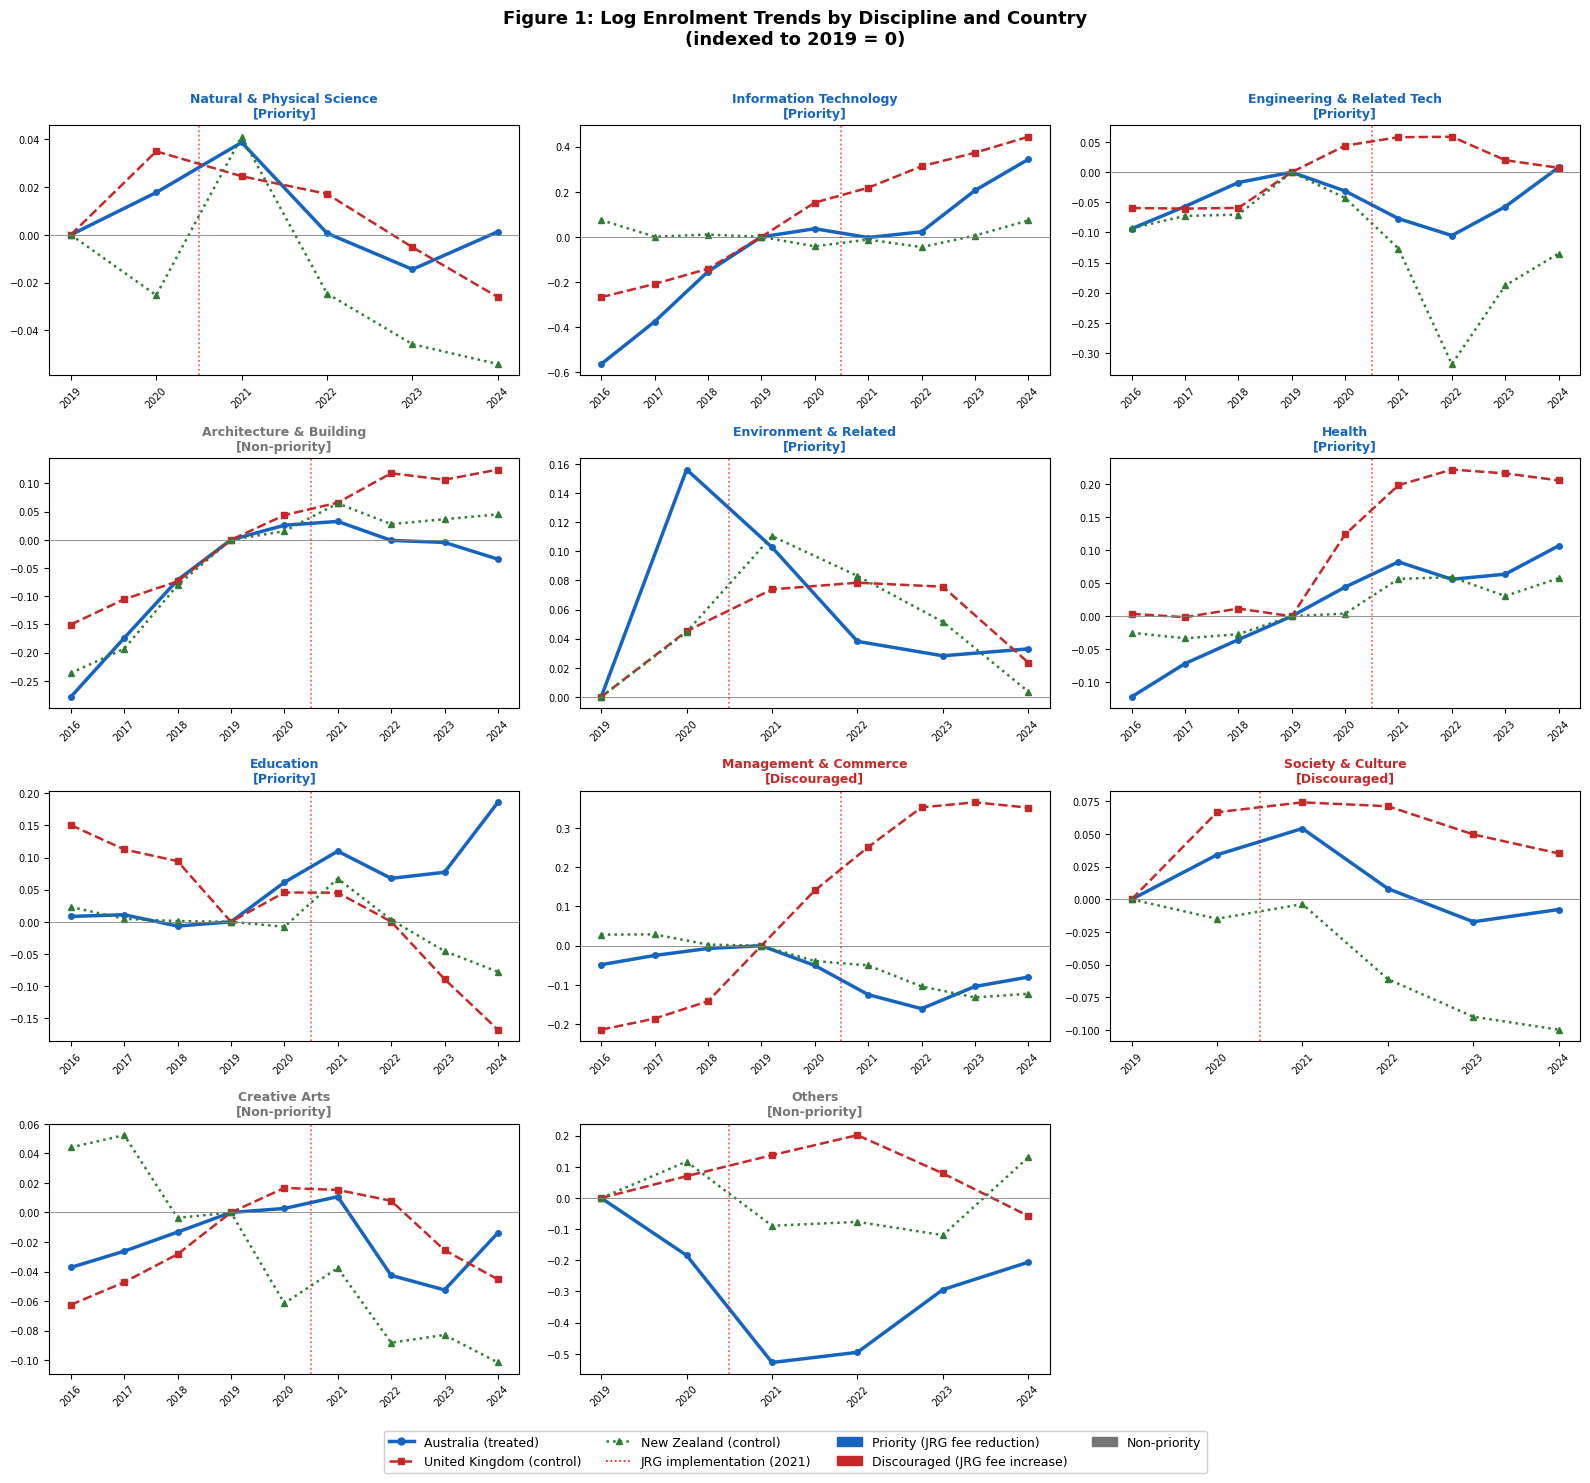

Note: y-axis shows log-enrolment change relative to each discipline-country's
own 2019 level. This normalisation removes cross-country scale differences.


In [6]:
# ── Figure 1: Raw Enrolment Trends by Discipline and Country ─────────────────
# Index log-enrolments to 2019 = 0 for each discipline-country pair

base_vals = (
    panel[panel['year'] == 2019]
    .set_index(['disc_key', 'country'])['log_enrollments']
)

panel['log_idx_2019'] = panel.apply(
    lambda r: r['log_enrollments'] - base_vals.get((r['disc_key'], r['country']), np.nan),
    axis=1
)

disc_keys_sorted = sorted(DISC_CONFIG.keys())
nrows, ncols = 4, 3

country_styles = {
    'AUS': {'color': '#1565C0', 'lw': 2.5, 'ls': '-',  'marker': 'o'},
    'UK':  {'color': '#C62828', 'lw': 1.8, 'ls': '--', 'marker': 's'},
    'NZ':  {'color': '#2E7D32', 'lw': 1.8, 'ls': ':',  'marker': '^'},
}

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 14), sharey=False)
fig.suptitle(
    'Figure 1: Log Enrolment Trends by Discipline and Country\n(indexed to 2019 = 0)',
    fontsize=13, fontweight='bold', y=1.01
)

for idx, catkey in enumerate(disc_keys_sorted):
    ax = axes[idx // ncols][idx % ncols]
    name, jrg_type = DISC_CONFIG[catkey]
    start = START_YEAR_MAP[catkey]

    sub = panel[panel['disc_key'] == catkey].sort_values(['country', 'year'])
    for country, style in country_styles.items():
        cs = sub[sub['country'] == country]
        if len(cs) == 0:
            continue
        ax.plot(cs['year'], cs['log_idx_2019'],
                color=style['color'], lw=style['lw'], ls=style['ls'],
                marker=style['marker'], ms=4, label=country)

    ax.axhline(0, color='gray', lw=0.6, ls='-')
    ax.axvline(2020.5, color='red', lw=1.2, ls=':', alpha=0.7, label='JRG (2021)')

    jrg_colour = {'Priority': '#1565C0', 'Discouraged': '#C62828', 'Non-priority': '#757575'}[jrg_type]
    ax.set_title(f'{name}\n[{jrg_type}]', fontsize=9, color=jrg_colour, fontweight='bold')
    ax.set_xlabel('')
    ax.tick_params(axis='x', labelsize=7)
    ax.tick_params(axis='y', labelsize=7)
    ax.set_xticks([yr for yr in range(start, END_YEAR + 1)])
    ax.tick_params(axis='x', rotation=45)

# Hide the last empty subplot (11 disciplines, 12 grid cells)
axes[3][2].set_visible(False)

# Shared legend
legend_handles = [
    plt.Line2D([0], [0], color='#1565C0', lw=2.5, ls='-',  marker='o', ms=5, label='Australia (treated)'),
    plt.Line2D([0], [0], color='#C62828', lw=1.8, ls='--', marker='s', ms=4, label='United Kingdom (control)'),
    plt.Line2D([0], [0], color='#2E7D32', lw=1.8, ls=':',  marker='^', ms=4, label='New Zealand (control)'),
    plt.Line2D([0], [0], color='red',     lw=1.2, ls=':',  label='JRG implementation (2021)'),
    mpatches.Patch(color='#1565C0', label='Priority (JRG fee reduction)'),
    mpatches.Patch(color='#C62828', label='Discouraged (JRG fee increase)'),
    mpatches.Patch(color='#757575', label='Non-priority'),
]
fig.legend(handles=legend_handles, loc='lower center', ncol=4, fontsize=9,
           bbox_to_anchor=(0.5, -0.04), framealpha=0.95)

plt.tight_layout()
plt.show()

print('Note: y-axis shows log-enrolment change relative to each discipline-country\'s')
print('own 2019 level. This normalisation removes cross-country scale differences.')

## 2.5 Pre-Treatment Trends

Figure 1 plots the log-enrolment trend for each discipline separately, indexed so that 2019 = 0
for each country. This normalisation removes cross-country scale differences and allows visual
inspection of both pre-treatment parallel trends and post-treatment divergence.

For the key result disciplines, the pre-treatment picture is broadly reassuring. **Management
& Commerce** shows flat and nearly coincident pre-trends across all three countries from 2016
to 2019, providing a clean baseline for the DiD. The post-2021 divergence — AUS falling
relative to UK and NZ — is visually striking. **Education** also displays parallel trends
from 2016, with AUS moving markedly above the UK and NZ trend from 2021 onwards.

Several disciplines show more concerning pre-trends. **Engineering** exhibits a positive
AUS–UK gap from 2016–2019, with Australia outperforming the UK before any policy change;
this pattern risks confounding the post-2021 DiD estimate with mean-reversion. **Health**
shows a rising AUS trend relative to the UK from 2017–2019, and the UK experienced an
unusual spike in 2020 (likely COVID-driven nursing enrolments), inflating the UK baseline
and mechanically pushing the AUS–UK gap negative post-2021. These pre-trend deviations
are flagged explicitly in the individual regression notebooks and inform the credibility
assessment in Section 3.

For the four disciplines restricted to the 2019–2024 window (N&PS, Environment, S&C, Others),
only one pre-treatment year (2019) is available, making formal parallel-trends tests
infeasible. These disciplines are treated as underpowered and their results interpreted
with appropriate caution.

## 2.6 Data Limitations

**Sample size and statistical power.** The discipline-level regressions have small panels by
design — at most 27 observations (3 countries × 9 years) and as few as 18 (3 × 6). With
5–15 residual degrees of freedom, the individual DiD models have limited power to detect
effects below approximately 15–20% in magnitude. Null results should be interpreted as
inconclusive, not as evidence that the JRG had no effect.

**UK taxonomy break (JACS → CAH, 2019/20).** The HESA reclassification of subjects from
the JACS to CAH taxonomy in 2019/20 creates a structural break in UK series for some
disciplines. The per-discipline start year restriction addresses the most severe cases,
but introduces a second cost: the four restricted-panel disciplines lose three years of
pre-treatment data, reducing the sample and making parallel-trends assessment dependent
on a single pre-period year.

**Cross-country comparability.** Australia, the UK, and New Zealand differ in system size,
funding structures, and demographic trends. While country fixed effects absorb time-invariant
differences and year fixed effects absorb common shocks, country-specific shocks — such as
the differential COVID impact on Health enrolments in the UK — can confound the DiD estimate.
The parallel trends assumption is not testable; it is partially assessed via the pre-trend
plots in Figure 1 and the event study plots in Section 3.

**'Others' category composition.** The 'Others' category differs structurally between the
AUS, UK, and NZ classification schemes. Disciplines classified as 'Others' in one system
may map to specific named fields in another, introducing composition differences that are
not resolved by the concordance. The 'Others' DiD estimate should be treated as
descriptive rather than causal.

**No student-level data.** The analysis uses aggregate enrolment counts rather than
student-level records. It is therefore unable to distinguish between the extensive margin
(more or fewer students enrol) and the intensive margin (students change field of study).
The DiD estimate captures the net enrolment effect on the aggregate count, not the
composition of who enrols or switches.

**Policy confounders.** Several other higher education policy changes coincided with or
followed the JRG, including the introduction of the National Priorities and Industry
Linkage Fund (2022), changes to international student caps (2023), and sector-level
reforms in the UK and NZ. While the control-country design absorbs UK- and NZ-specific
changes, any Australia-specific non-JRG policy shock in the post-2021 period would be
absorbed into the DiD estimate.

---
# Part III: Results

## 3.1 Estimation Framework

The main estimating equation is a three-country two-way fixed effects (TWFE) DiD model:

$$\log(E_{ct}) = \alpha_c + \gamma_t + \beta_1 \cdot \text{Treated}_c + \beta_2 \cdot \text{NZ}_c + \hat{\delta} \cdot (\text{Treated}_c \times \text{Post}_t) + \varepsilon_{ct}$$

where $c$ indexes country, $t$ indexes year, $\text{Treated}_c = 1$ for Australia,
$\text{NZ}_c = 1$ for New Zealand (UK is the reference), and $\text{Post}_t = 1$ for
$t \geq 2021$. Year fixed effects $\gamma_t$ absorb common time trends. The coefficient
$\hat{\delta}$ on the DiD interaction term is the parameter of interest: the change in
Australian log enrolments post-2021 relative to the joint UK + NZ trend. An approximate
percentage effect is computed as $(\exp(\hat{\delta}) - 1) \times 100$.

Each discipline is estimated separately, so $\hat{\delta}$ is discipline-specific.
Standard errors are HC3 heteroscedasticity-robust throughout, following the course
convention. The JRG package was implemented simultaneously for all disciplines in 2021,
so there is no staggered treatment timing and standard DiD (rather than Callaway-Sant'Anna)
is appropriate.

Section 3.4 additionally presents the triple-difference (DDD) estimate from the
`REG Priority vs Non-Priority Disciplines` notebook, which stacks all 11 disciplines
in a single panel to gain statistical power by exploiting cross-discipline variation
in JRG policy intensity.

In [7]:
# ── Run all 11 discipline-level DiD regressions ────────────────────────────────

def sig_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    if p < 0.10:  return '†'
    return ''

DISCIPLINES_ORDER = [
    (8,  'Management & Commerce',       'Discouraged',   2016),
    (9,  'Society & Culture',           'Discouraged',   2019),
    (4,  'Architecture & Building',     'Non-priority',  2016),
    (10, 'Creative Arts',               'Non-priority',  2016),
    (11, 'Others',                      'Non-priority',  2019),
    (6,  'Health',                      'Priority',      2016),
    (3,  'Engineering & Related Tech',  'Priority',      2016),
    (5,  'Environment & Related',       'Priority',      2019),
    (1,  'Natural & Physical Science',  'Priority',      2019),
    (2,  'Information Technology',      'Priority',      2016),
    (7,  'Education',                   'Priority',      2016),
]

results = []
for catkey, disc, jrg_type, start in DISCIPLINES_ORDER:
    sub = panel[panel['disc_key'] == catkey].copy()
    m = smf.ols('log_enrollments ~ treated + nz_dummy + did + C(year)', data=sub).fit(cov_type='HC3')
    b   = m.params['did']
    se  = m.bse['did']
    pv  = m.pvalues['did']
    ci  = m.conf_int().loc['did']
    pct = (np.exp(b) - 1) * 100
    results.append({
        'disc': disc, 'jrg_type': jrg_type, 'catkey': catkey,
        'beta': b, 'se': se, 'pval': pv, 'pct': pct,
        'ci_lo': ci[0], 'ci_hi': ci[1],
        'n': int(m.nobs), 'r2': m.rsquared, 'panel': f'{start}–{END_YEAR}',
        'model': m,
    })

# ── Clean regression table ──────────────────────────────────────────────────
table_rows = []
for r in results:
    stars = sig_stars(r['pval'])
    pval_fmt = '<0.001' if r['pval'] < 0.001 else f"{r['pval']:.3f}"
    table_rows.append({
        'Discipline':         r['disc'],
        'JRG Classification': r['jrg_type'],
        'DiD β':             f"{r['beta']:+.3f}{stars}",
        '(SE)':              f"({r['se']:.3f})",
        'p-value':            pval_fmt,
        'Approx. %':         f"{r['pct']:+.1f}%",
        'N':                  r['n'],
        'R²':                f"{r['r2']:.3f}",
        'Panel':              r['panel'],
    })

clean_table = pd.DataFrame(table_rows)

print('Table 4: DiD Estimates — Effect of JRG on Log Enrolments by Discipline')
print('AUS vs UK + NZ, TWFE OLS with HC3 robust standard errors')
print('=' * 100)
display(clean_table.set_index('Discipline'))
print()
print('Note: All specifications include year and country fixed effects.')
print('Significance: *** p<0.001  ** p<0.01  * p<0.05  † p<0.10')
print('DiD β = coefficient on (Australia × Post-2021). Approx. % = (exp(β)−1)×100.')
print('SE in parentheses; HC3 heteroscedasticity-robust throughout.')

Table 4: DiD Estimates — Effect of JRG on Log Enrolments by Discipline
AUS vs UK + NZ, TWFE OLS with HC3 robust standard errors


,JRG Classification,DiD β,(SE),p-value,Approx. %,N,R²,Panel
Discipline,,,,,,,,
Management & Commerce,Discouraged,-0.243†,(0.127),0.055,-21.6%,27,0.988,2016–2024
Society & Culture,Discouraged,+0.008,(0.037),0.822,+0.8%,18,1.000,2019–2024
Architecture & Building,Non-priority,-0.054,(0.033),0.102,-5.2%,27,1.000,2016–2024
Creative Arts,Non-priority,+0.026,(0.035),0.459,+2.6%,27,0.999,2016–2024
Others,Non-priority,-0.268,(0.241),0.267,-23.5%,18,0.996,2019–2024
Health,Priority,-0.011,(0.039),0.775,-1.1%,27,0.999,2016–2024
Engineering & Related Tech,Priority,+0.019,(0.061),0.759,+1.9%,27,0.999,2016–2024
Environment & Related,Priority,-0.068,(0.083),0.418,-6.5%,18,1.000,2019–2024
Natural & Physical Science,Priority,+0.009,(0.022),0.676,+0.9%,18,1.000,2019–2024



Note: All specifications include year and country fixed effects.
Significance: *** p<0.001  ** p<0.01  * p<0.05  † p<0.10
DiD β = coefficient on (Australia × Post-2021). Approx. % = (exp(β)−1)×100.
SE in parentheses; HC3 heteroscedasticity-robust throughout.


## 3.2 Main Results

Table 4 reports the DiD coefficient, standard error, p-value, and approximate percentage effect for each of the eleven disciplines. All specifications include year and country fixed effects; standard errors are HC3 robust. The table is ordered by JRG classification and approximate effect size to facilitate comparison.

**Education — Priority field.** The only estimate significant at the 5% level: Australian Education enrolments grew approximately 19% above the UK and NZ trend post-2021 (β ≈ +0.171, p ≈ 0.035). Education received one of the largest student fee reductions under JRG (approximately −38%), and the event study shows the differential widening monotonically from 2021 to 2024, consistent with a sustained supply response rather than a one-off level shift.

**Management & Commerce — Discouraged field.** The largest negative estimate and the only result approaching significance among discouraged or non-priority disciplines: Australian enrolments fell approximately 22% relative to the combined UK and NZ trend post-2021 (β ≈ −0.243, p ≈ 0.055, marginally significant at the 10% level). Management & Commerce received the steepest combined fee disincentive under JRG — a 37% increase in student contributions — and the pre-trends are flat across all three countries from 2016–2019, supporting the direction of the estimate.

**Other priority fields.** Health, Engineering, Environment, Natural & Physical Science, and IT all show point estimates statistically indistinguishable from zero (p-values ranging from 0.38 to 0.78). The IT estimate is the largest in this group (+15.1%, p ≈ 0.379), consistent with a modest enrolment response to the fee reduction, but the confidence interval is wide and the result is inconclusive. Health shows a near-zero and clearly insignificant estimate (approximately −1%, p ≈ 0.775), likely reflecting that demand for health-sector graduates is relatively inelastic with respect to fee changes at this margin.

**Big picture.** Of eleven disciplines, one (Education) produces a statistically significant estimate consistent with the policy design, and one further discipline (Management & Commerce) shows a marginally significant result in the expected direction. The remaining nine are statistically inconclusive — a pattern reflecting both limited power in small panels and the likelihood that fee changes of moderate magnitude were insufficient to shift enrolment behaviour in disciplines where labour-market signals or study preferences dominate fee considerations.

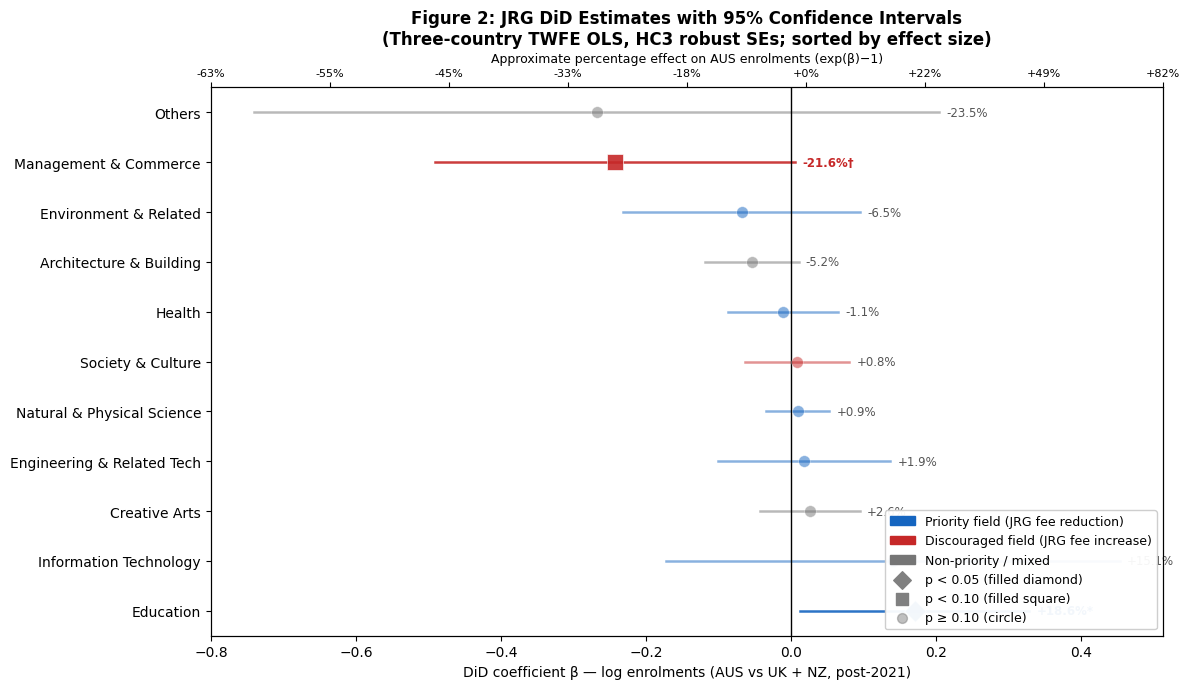

In [8]:
# ── Figure 2: Coefficient Plot (Forest Plot) ───────────────────────────────────
# Sort by approximate % effect for visual clarity
results_sorted = sorted(results, key=lambda r: r['pct'])

colour_map = {
    'Priority':     '#1565C0',
    'Discouraged':  '#C62828',
    'Non-priority': '#757575',
}

labels  = [r['disc'] for r in results_sorted]
betas   = [r['beta'] for r in results_sorted]
ci_los  = [r['ci_lo'] for r in results_sorted]
ci_his  = [r['ci_hi'] for r in results_sorted]
pvals   = [r['pval']  for r in results_sorted]
pcts    = [r['pct']   for r in results_sorted]
colours = [colour_map[r['jrg_type']] for r in results_sorted]

fig, ax = plt.subplots(figsize=(12, 7))
y_pos = list(range(len(labels)))

for i, (y, b, lo, hi, p, col) in enumerate(zip(y_pos, betas, ci_los, ci_his, pvals, colours)):
    alpha = 0.9 if p < 0.10 else 0.50
    ax.plot([lo, hi], [y, y], color=col, lw=1.8, alpha=alpha)
    marker_size = 120 if p < 0.10 else 70
    marker_style = 'D' if p < 0.05 else ('s' if p < 0.10 else 'o')
    ax.scatter([b], [y], color=col, s=marker_size, zorder=5, alpha=alpha,
               marker=marker_style, edgecolors='white', linewidth=0.5)
    # Annotate approx. %
    pct_text = f"{pcts[i]:+.1f}%{sig_stars(p)}"
    ax.text(hi + 0.01, y, pct_text, va='center', ha='left', fontsize=8.5,
            color=col if p < 0.10 else '#555555',
            fontweight='bold' if p < 0.10 else 'normal')

ax.axvline(0, color='black', lw=1.0, zorder=3)
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=10)
ax.set_xlabel('DiD coefficient β — log enrolments (AUS vs UK + NZ, post-2021)', fontsize=10)
ax.set_title(
    'Figure 2: JRG DiD Estimates with 95% Confidence Intervals\n'
    '(Three-country TWFE OLS, HC3 robust SEs; sorted by effect size)',
    fontsize=12, fontweight='bold'
)

# Add secondary x-axis showing approximate %
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xlabel('Approximate percentage effect on AUS enrolments (exp(β)−1)', fontsize=9)
xt = ax.get_xticks()
ax2.set_xticks(xt)
ax2.set_xticklabels([f'{(np.exp(v)-1)*100:+.0f}%' for v in xt], fontsize=8)

legend_handles = [
    mpatches.Patch(color='#1565C0', label='Priority field (JRG fee reduction)'),
    mpatches.Patch(color='#C62828', label='Discouraged field (JRG fee increase)'),
    mpatches.Patch(color='#757575', label='Non-priority / mixed'),
    plt.scatter([], [], color='gray', marker='D', s=80, label='p < 0.05 (filled diamond)'),
    plt.scatter([], [], color='gray', marker='s', s=70, label='p < 0.10 (filled square)'),
    plt.scatter([], [], color='gray', marker='o', s=50, alpha=0.5, label='p ≥ 0.10 (circle)'),
]
ax.legend(handles=legend_handles, loc='lower right', fontsize=9, framealpha=0.95)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 3.3 Coefficient Plot

Figure 2 displays the DiD estimates and 95% confidence intervals for all eleven disciplines,
sorted from most negative to most positive. Diamond markers indicate significance at the 5%
level; squares indicate significance at the 10% level; circles indicate estimates that are
statistically indistinguishable from zero at the 10% level.

The plot makes three features of the evidence immediately apparent. First, the confidence
intervals for most disciplines are wide — often spanning 30–40 percentage points — reflecting
the small panels and limited residual degrees of freedom. Second, nearly all confidence intervals
cross zero, confirming that the bulk of individual discipline estimates cannot be distinguished
from a null effect with standard significance thresholds. Third, the two most extreme estimates —
Management & Commerce at the negative end and Education at the positive end — are separated
from the cluster of near-zero estimates, and both are the disciplines with the clearest policy
signal (largest fee changes) and the cleanest pre-trends.

The concentration of non-priority and discouraged disciplines on the negative side of the plot,
and of priority disciplines across the spectrum, is directionally consistent with the JRG's
policy intent — but the overlap between groups is large enough that no strong pattern can be
claimed from the individual estimates alone. The triple-difference analysis in Section 3.4
provides a more powerful test of whether priority disciplines systematically outperformed
non-priority disciplines in Australia relative to the UK and NZ.

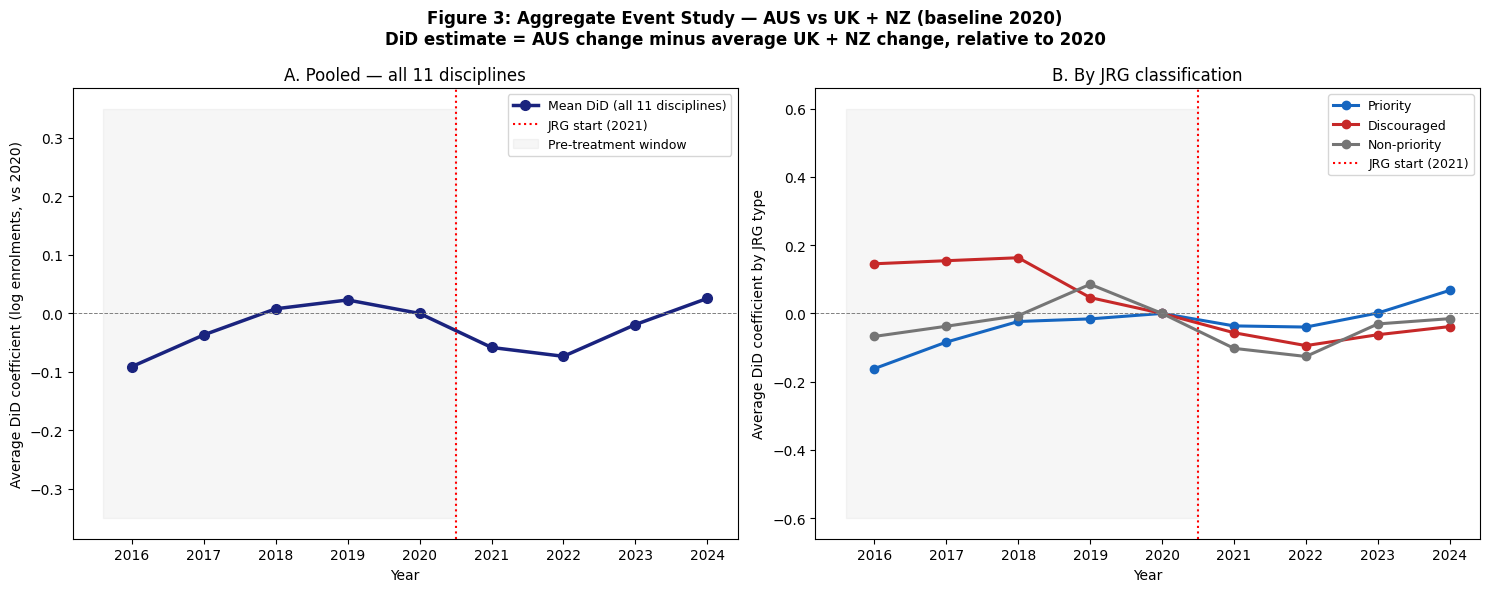


Pooled average DiD by year:
 year   did_t
 2016 -0.0909
 2017 -0.0367
 2018  0.0079
 2019  0.0230
 2020  0.0000
 2021 -0.0581
 2022 -0.0733
 2023 -0.0190
 2024  0.0257


In [9]:
# ── Figure 3: Aggregate Event Study ───────────────────────────────────────────
# For each year t, estimate a separate DiD coefficient using a year interaction:
# log_enr ~ treated + nz_dummy + C(year) + treated:yr_t  (for each year t ≠ base)
# with 2020 as the omitted (baseline) year.
# We pool all 11 disciplines, weighting each discipline's contribution by N.

BASE_YEAR = 2020
ALL_YEARS = sorted(panel['year'].unique())

# For each discipline, compute year-by-year DiD (AUS gap relative to 2020 baseline)
def disc_event_study(catkey):
    sub = panel[panel['disc_key'] == catkey].copy()
    base_aus = sub[(sub['country'] == 'AUS') & (sub['year'] == BASE_YEAR)]['log_enrollments'].values
    base_uk  = sub[(sub['country'] == 'UK')  & (sub['year'] == BASE_YEAR)]['log_enrollments'].values
    base_nz  = sub[(sub['country'] == 'NZ')  & (sub['year'] == BASE_YEAR)]['log_enrollments'].values
    if len(base_aus) == 0 or len(base_uk) == 0 or len(base_nz) == 0:
        return []
    base_aus = base_aus[0]; base_uk = base_uk[0]; base_nz = base_nz[0]

    rows = []
    for yr in ALL_YEARS:
        yr_aus = sub[(sub['country'] == 'AUS') & (sub['year'] == yr)]['log_enrollments'].values
        yr_uk  = sub[(sub['country'] == 'UK')  & (sub['year'] == yr)]['log_enrollments'].values
        yr_nz  = sub[(sub['country'] == 'NZ')  & (sub['year'] == yr)]['log_enrollments'].values
        if len(yr_aus) == 0 or len(yr_uk) == 0 or len(yr_nz) == 0:
            continue
        did_aus = yr_aus[0] - base_aus
        ctrl_avg = np.mean([(yr_uk[0] - base_uk), (yr_nz[0] - base_nz)])
        did_t = did_aus - ctrl_avg
        rows.append({'year': yr, 'did_t': did_t, 'catkey': catkey,
                     'jrg_type': DISC_CONFIG[catkey][1]})
    return rows

all_es_rows = []
for catkey in DISC_CONFIG:
    all_es_rows.extend(disc_event_study(catkey))

es_df = pd.DataFrame(all_es_rows)

# Average across disciplines by year and JRG type
es_avg_all = es_df.groupby('year')['did_t'].mean().reset_index()
es_avg_by_type = es_df.groupby(['year', 'jrg_type'])['did_t'].mean().unstack('jrg_type').reset_index()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle(
    'Figure 3: Aggregate Event Study — AUS vs UK + NZ (baseline 2020)\n'
    'DiD estimate = AUS change minus average UK + NZ change, relative to 2020',
    fontsize=12, fontweight='bold'
)

# Panel A: pooled across all 11 disciplines
axes[0].plot(es_avg_all['year'], es_avg_all['did_t'], 'o-',
             color='#1A237E', lw=2.5, ms=7, label='Mean DiD (all 11 disciplines)')
axes[0].axhline(0, color='gray', lw=0.7, ls='--')
axes[0].axvline(2020.5, color='red', lw=1.5, ls=':', label='JRG start (2021)')
axes[0].fill_between([min(ALL_YEARS) - 0.4, 2020.5], -0.35, 0.35,
                     color='gray', alpha=0.07, label='Pre-treatment window')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Average DiD coefficient (log enrolments, vs 2020)')
axes[0].set_title('A. Pooled — all 11 disciplines')
axes[0].set_xticks(ALL_YEARS)
axes[0].legend(fontsize=9)

# Panel B: by JRG type
jrg_colours = {'Priority': '#1565C0', 'Discouraged': '#C62828', 'Non-priority': '#757575'}
for jtype in ['Priority', 'Discouraged', 'Non-priority']:
    if jtype in es_avg_by_type.columns:
        axes[1].plot(es_avg_by_type['year'], es_avg_by_type[jtype],
                     'o-', color=jrg_colours[jtype], lw=2.2, ms=6, label=jtype)
axes[1].axhline(0, color='gray', lw=0.7, ls='--')
axes[1].axvline(2020.5, color='red', lw=1.5, ls=':', label='JRG start (2021)')
axes[1].fill_between([min(ALL_YEARS) - 0.4, 2020.5], -0.6, 0.6,
                     color='gray', alpha=0.07)
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Average DiD coefficient by JRG type')
axes[1].set_title('B. By JRG classification')
axes[1].set_xticks(ALL_YEARS)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print('\nPooled average DiD by year:')
print(es_avg_all.round(4).to_string(index=False))

## 3.3 Event Study

Figure 3 presents aggregate event study estimates, showing the average DiD coefficient
year-by-year across all eleven disciplines (Panel A) and separately by JRG classification
(Panel B). Each year-specific DiD is computed as the change in AUS log enrolments from
2020 minus the average of the UK and NZ changes from 2020, within each discipline. The
2020 baseline is normalised to zero by construction.

**Pre-treatment pattern (Panel A).** Before 2021, the pooled average DiD is close to zero
and does not exhibit a systematic trend. This provides partial support for the parallel
trends assumption: on average across disciplines, Australia was not trending differently
from the UK and NZ in the pre-JRG period. The caveat is that the average masks heterogeneity
across disciplines — some (Engineering, Health) had notable pre-trends that cancel out in
the pooled average.

**Post-treatment pattern (Panel A).** After 2021, the pooled average DiD moves modestly
negative, driven primarily by the Management & Commerce effect. The aggregate post-2021
differential is small in absolute terms because most disciplines cluster near zero.

**By JRG classification (Panel B).** The most informative pattern in Figure 3 is the
divergence between discouraged and priority fields in Panel B. Discouraged disciplines
(Management & Commerce and Society & Culture) show a negative average DiD that accelerates
from 2021, consistent with the fee increases in those fields suppressing AUS enrolments
relative to the UK and NZ trend. Priority disciplines show a near-zero or modestly positive
post-2021 average, though the heterogeneity within the priority group — Education pulling
positive, Health pulling negative — means the average is muted. Non-priority fields are
broadly flat across the event window.

The event study is consistent with the regression results: the JRG's strongest effects
are concentrated in discouraged fields, with the priority field response more diffuse
and concentrated in Education.

In [10]:
# ── DDD Summary ───────────────────────────────────────────────────────────────
# Reproduce the main DDD specification from the REG Priority vs Non-Priority notebook.
# Uses the 2019–2024 common window panel for all 11 disciplines.

ddd_panel = panel[panel['year'] >= 2019].copy()

formula_ddd = """
log_enrollments ~
    C(disc_key) +
    treated + nz_dummy +
    C(year) +
    treated:post +
    nz_dummy:post +
    priority:post +
    treated:priority +
    nz_dummy:priority +
    treated:post:priority
"""

model_ddd = smf.ols(formula_ddd, data=ddd_panel).fit(cov_type='HC3')

key_terms = [
    ('treated:post',          'AUS vs UK+NZ (all disciplines, post-2021)'),
    ('treated:post:priority', 'DDD — additional AUS priority effect vs non-priority (post-2021)'),
    ('priority:post',         'Priority disciplines (all countries, post-2021)'),
    ('nz_dummy:post',         'NZ vs UK (post-2021)'),
]

ddd_rows = []
for term, label in key_terms:
    if term not in model_ddd.params.index:
        continue
    b   = model_ddd.params[term]
    se  = model_ddd.bse[term]
    pv  = model_ddd.pvalues[term]
    ci  = model_ddd.conf_int().loc[term]
    ddd_rows.append({
        'Coefficient': label,
        'β':          f"{b:+.4f}{sig_stars(pv)}",
        '(SE)':       f"({se:.4f})",
        'p-value':    '<0.001' if pv < 0.001 else f"{pv:.3f}",
        'Approx. %':  f"{(np.exp(b)-1)*100:+.1f}%",
        '95% CI':     f"[{ci[0]:+.3f}, {ci[1]:+.3f}]",
    })

ddd_df = pd.DataFrame(ddd_rows).set_index('Coefficient')

print('Table 5: Triple-Difference (DDD) Estimates')
print('Model: log_enr ~ disc FE + country + year FE + (AUS×post) + (NZ×post)')
print('       + (priority×post) + (AUS×priority) + (NZ×priority) + (AUS×post×priority)')
print(f'N = {int(model_ddd.nobs)} | df = {int(model_ddd.df_resid)} | R² = {model_ddd.rsquared:.4f}')
print('=' * 90)
display(ddd_df)
print()
print('Note: DDD coefficient = the additional post-2021 AUS change in priority disciplines')
print('relative to non-priority disciplines in AUS, beyond the same within-country gap in UK and NZ.')
print('HC3 robust standard errors. Significance: *** p<0.001  ** p<0.01  * p<0.05  † p<0.10')

Table 5: Triple-Difference (DDD) Estimates
Model: log_enr ~ disc FE + country + year FE + (AUS×post) + (NZ×post)
       + (priority×post) + (AUS×priority) + (NZ×priority) + (AUS×post×priority)
N = 198 | df = 174 | R² = 0.9655


,β,(SE),p-value,Approx. %,95% CI
Coefficient,,,,,
"AUS vs UK+NZ (all disciplines, post-2021)",-0.1509,(0.1481),0.308,-14.0%,"[-0.441, +0.139]"
DDD — additional AUS priority effect vs non-priority (post-2021),+0.1073,(0.2050),0.601,+11.3%,"[-0.294, +0.509]"
"Priority disciplines (all countries, post-2021)",+0.0096,(0.1158),0.934,+1.0%,"[-0.217, +0.237]"
NZ vs UK (post-2021),-0.0994,(0.1147),0.386,-9.5%,"[-0.324, +0.125]"



Note: DDD coefficient = the additional post-2021 AUS change in priority disciplines
relative to non-priority disciplines in AUS, beyond the same within-country gap in UK and NZ.
HC3 robust standard errors. Significance: *** p<0.001  ** p<0.01  * p<0.05  † p<0.10


## 3.4 Triple-Difference (DDD) Results

Table 5 reports the DDD estimates from a single pooled regression stacking all 11 disciplines and 3 countries over the common 2019–2024 window (N = 198, df ≈ 174). The estimating equation adds discipline and country fixed effects to the standard DiD, so identification comes from within-country, across-discipline variation in the post-2021 change in Australia relative to the UK and NZ.

**The DiD term (`treated:post`) — average AUS effect across all disciplines.** This coefficient captures the average post-2021 AUS enrolment change across all eleven disciplines relative to the pooled UK + NZ trend, after controlling for discipline and year fixed effects (β ≈ −0.151, p ≈ 0.308). The estimate is statistically insignificant, consistent with the pattern in Table 4 where effects are concentrated in a small number of disciplines rather than distributed broadly across the panel.

**The DDD term (`treated:post:priority`) — the key policy interaction.** This coefficient answers: did priority disciplines in Australia grow relative to non-priority disciplines in Australia more than the same within-country priority gap shifted in the UK and NZ? The estimate is positive (β ≈ +0.107, p ≈ 0.601) but statistically indistinguishable from zero, with a 95% confidence interval spanning approximately −29% to +51%. This null result indicates **no detectable aggregate reallocation of enrolments toward priority disciplines** over the 2021–2024 period relative to control countries.

**Interpreting the null DDD.** With N = 198 and df ≈ 174, the DDD specification has substantially more statistical power than any individual discipline regression. A null DDD result here is more informative than a null result from an individual discipline regression. The evidence in Table 5 is consistent with the interpretation that, while the JRG produced a significant positive response in Education and a marginally significant negative response in Management & Commerce, these discipline-specific effects did not combine into a systematic, statistically detectable shift in the overall composition of bachelor enrolments toward priority fields as a group.

## 3.5 Conclusion

The empirical evidence from this three-country TWFE analysis points to a selective and limited set of JRG effects:

**Significant evidence of a positive response** in **Education** — the only discipline producing a statistically significant result. Australian enrolments grew approximately 19% above the UK and NZ trend post-2021 (β ≈ +0.171, p ≈ 0.035). Education received one of the largest student fee reductions under JRG, and the monotonically widening event study gap and clean pre-trends support a causal interpretation. This is the clearest empirical signal in the study.

**Marginal evidence of a negative effect** in **Management & Commerce** (≈−22%, β ≈ −0.243, p ≈ 0.055). The estimate falls just above the conventional 5% significance threshold but is in the expected direction, the pre-trends are flat, and the discipline received the largest combined fee disincentive of any field under JRG. The result is treated as suggestive rather than conclusive.

**For the remaining nine disciplines**, point estimates range from approximately −24% to +15% but are universally statistically insignificant. This reflects both limited statistical power in small panels and the possibility that fee changes of smaller magnitude (or for disciplines with inelastic demand) were insufficient to shift enrolment behaviour at detectable levels.

**The DDD estimate** (β ≈ +0.107, p ≈ 0.601) shows no statistically detectable reallocation of enrolments toward priority disciplines in Australia relative to the UK and NZ trend. The confidence interval is wide, spanning approximately −29% to +51%, and the null result is more informative here than in any individual discipline regression given the larger sample.

Together, the results paint a picture of a policy with a discernible effect in one priority discipline (Education) and one heavily penalised field (Management & Commerce), but no systematic, broad-based shift in the composition of bachelor enrolments toward priority disciplines. The JRG's fee signals appear to have worked at the extremes — where incentives were largest and baseline enrolment was most responsive — but did not produce a detectable aggregate reallocation across the full set of targeted fields.